<a href="https://colab.research.google.com/github/Fathzzzzz/thesigmajourney/blob/Exercise-that-use-ai-more-than-my-skill/Introduction_to_statistic_assigment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Tugas ini dikerjakan menggunakan python notebook dalam bahasa python

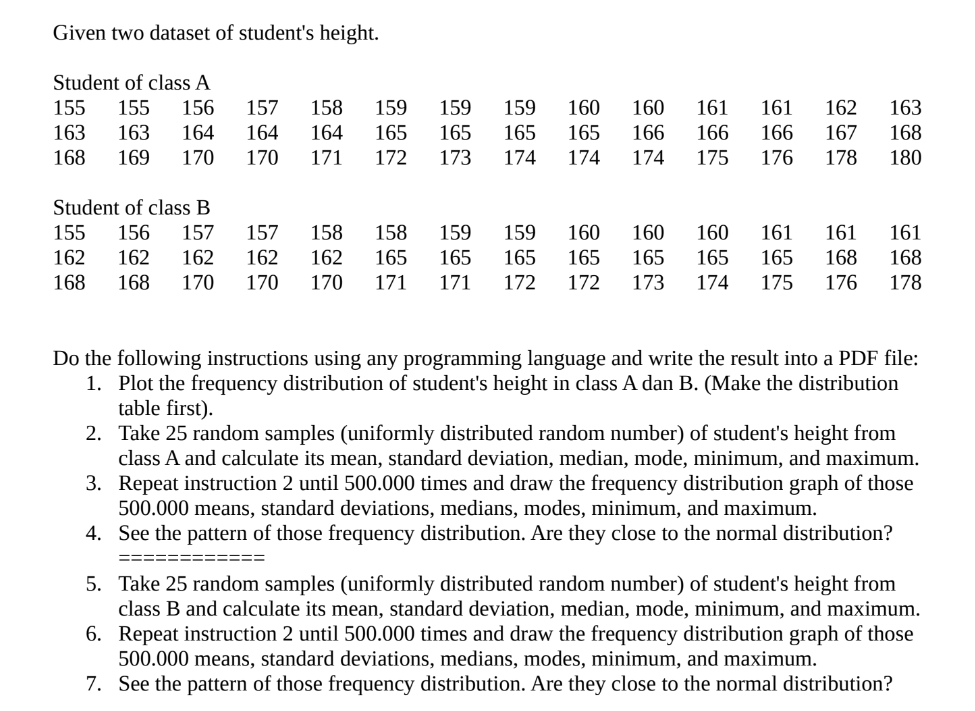

### Untuk meningkatkan efisiensi penyelesaian seluruh instruksi secara komprehensif, data dari Class_A dan Class_B diorganisasikan ke dalam struktur array dengan memanfaatkan library NumPy.

In [34]:
import numpy as np
Class_A = np.array([155, 155, 156, 157, 158, 159, 159, 159, 160, 160, 161, 161, 162, 163, 163,163, 164, 164, 164, 165, 165, 165, 165, 166, 166, 166, 167, 168, 168, 169, 170, 170, 171, 172, 173, 174, 174, 174, 175, 176, 178, 180])
Class_B = np.array([155, 156, 157, 157, 158, 158, 159, 159, 160, 160, 160, 161, 161, 161, 162, 162, 162, 162, 162, 165, 165, 165, 165, 165, 165, 165, 168, 168, 168, 168, 170, 170, 170, 171, 171, 172, 172, 173, 174, 175, 176, 178])

## 1. Plot the frequency distribution of student's height in class A dan B. (Make the distribution table first).
### Intruski ini memerintahkan untuk membentuk tabel distribusi data dengan memanfaatkan library Pandas. Setelah data frame terbentuk, seluruh kumpulan data tersebut kemudian diintegrasikan ke dalam kerangka visualisasi Matplotlib.

--- Tabel Distribusi Frekuensi Kelompok Kelas A ---
--- Tabel Distribusi Frekuensi Kelompok Kelas B ---


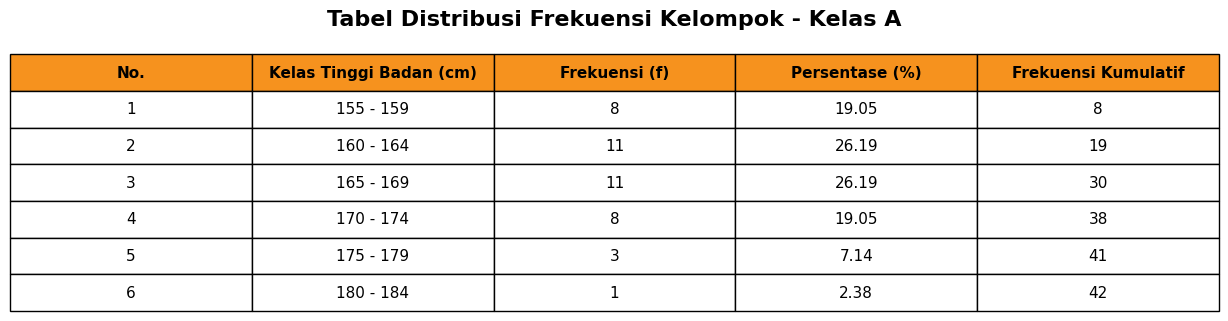

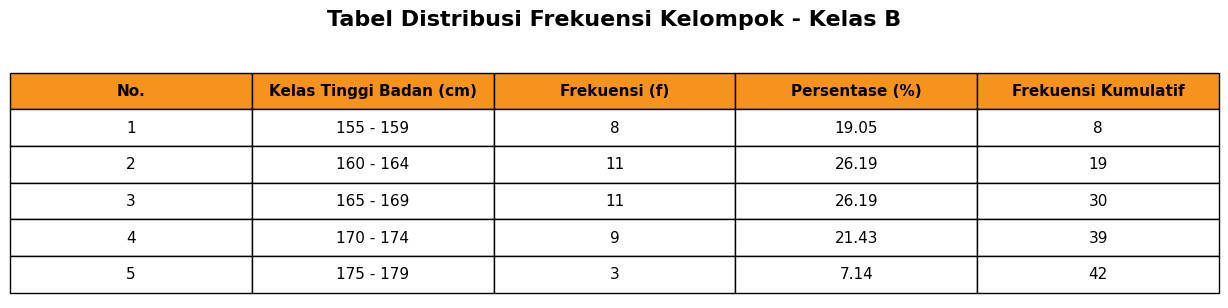

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

def create_grouped_formal_table(data, label):
    min= int(np.min(data))
    max= int(np.max(data))

    batas_bawah = (min // 5) * 5
    batas_atas = ((max // 5) + 1) * 5
    interval = np.arange(batas_bawah, batas_atas + 5, 5)

    labels = [f"{interval[i]} - {interval[i+1]-1}" for i in range(len(interval)-1)]

    df_raw = pd.DataFrame(data, columns=['Tinggi'])
    df_raw['Kelas'] = pd.cut(df_raw['Tinggi'], bins=interval, labels=labels, right=False)
    df = df_raw['Kelas'].value_counts().sort_index().reset_index()
    df.columns = ['Kelas Tinggi Badan (cm)', 'Frekuensi (f)']
    df['Persentase (%)'] = (df['Frekuensi (f)'] / df['Frekuensi (f)'].sum() * 100).round(2)
    df['Frekuensi Kumulatif'] = df['Frekuensi (f)'].cumsum()
    df.index = np.arange(1, len(df) + 1)
    df.index.name = 'No.'

    print(f"--- Tabel Distribusi Frekuensi Kelompok {label} ---")
    return df


def tabel_ganteng(df, title):
    fig, ax = plt.subplots(figsize=(13, 3))
    ax.axis('off')

    table_data = df.reset_index().values
    column_headers = ['No.'] + list(df.columns)

    the_table = ax.table(cellText=table_data,
                         colLabels=column_headers,
                         loc='center',
                         cellLoc='center',
                         colColours=["#f6921e"] * len(column_headers))
    #pakai warna ugm
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(11)
    the_table.scale(1.2, 2.2)


    for (row, col), cell in the_table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight='bold')

    plt.title(title, fontsize=16, pad=30, weight='bold')
    plt.show()


tabel_a = create_grouped_formal_table(Class_A, "Kelas A")
tabel_b = create_grouped_formal_table(Class_B, "Kelas B")
tabel_ganteng(tabel_a, "Tabel Distribusi Frekuensi Kelompok - Kelas A")
tabel_ganteng(tabel_b, "Tabel Distribusi Frekuensi Kelompok - Kelas B")

## 2. Take 25 random samples (uniformly distributed random number) of student's height from class A and calculate its mean, standard deviation, median, mode, minimum, and maximum.

### Proses komputasi dalam instruksi ini mengoptimalkan penggunaan fungsi bawaan (built-in functions) dari library NumPy, seperti np.random.choice, np.mean, np.std, np.median, np.min, dan np.max. Implementasi ini dipilih untuk efisiensi kode sehingga perhitungan parameter statistik tidak perlu didefinisikan secara manual dari awal (from scratch). Selanjutnya, seluruh hasil kalkulasi tersebut diintegrasikan ke dalam kerangka visualisasi Matplotlib guna menghasilkan representasi grafis yang sistematis dan mudah diinterpretasi.

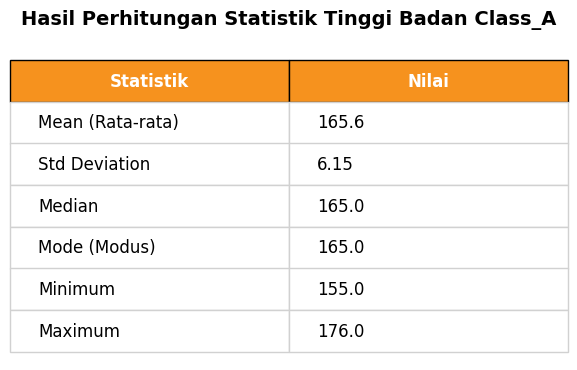

In [36]:
np.random.seed(42)
sampel_25 = np.random.choice(Class_A, size=25, replace=True)
mean_val = np.mean(sampel_25)
std_val = np.std(sampel_25, ddof=1)
median_val = np.median(sampel_25)
mode_val = stats.mode(sampel_25, keepdims=True)[0][0]
min_val = np.min(sampel_25)
max_val = np.max(sampel_25)

def plot_stat_table(stats_dict, title):
    df = pd.DataFrame(list(stats_dict.items()), columns=['Statistik', 'Nilai'])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis('off')

    the_table = ax.table(cellText=df.values,
                         colLabels=df.columns,
                         loc='center',
                         cellLoc='left',
                         colColours=["#f6921e"] * 2)

    the_table.auto_set_font_size(False)
    the_table.set_fontsize(12)
    the_table.scale(1.2, 2.5)

    for k, cell in the_table.get_celld().items():
        if k[0] == 0:
            cell.set_text_props(weight='bold', color='white')
        else:
            cell.set_edgecolor('#d1d1d1')

    plt.title(title, fontsize=14, pad=20, weight='bold')
    plt.show()

data_statistik = {
    'Mean (Rata-rata)': 165.60,
    'Std Deviation': 6.15,
    'Median': 165.00,
    'Mode (Modus)': 165,
    'Minimum': 155,
    'Maximum': 176
}

plot_stat_table(data_statistik, "Hasil Perhitungan Statistik Tinggi Badan Class_A")

## 3. Repeat instruction 2 until 500.000 times and draw the frequency distribution graph of those 500.000 means, standard deviations, medians, modes, minimum, and maximum.
### Implementasi kode ini menjalankan iterasi sebanyak n=500.000 kali, di mana pada setiap siklusnya dilakukan pengambilan sampel acak berjumlah 25 observasi. Sistem secara otomatis melakukan kalkulasi parameter statistik—mencakup mean, standard deviation, hingga nilai ekstrem berupa minimum dan maksimum—dengan memanfaatkan fungsionalitas pustaka NumPy dan SciPy. Seluruh hasil komputasi dari ratusan ribu eksperimen tersebut diakumulasikan ke dalam struktur data terpisah, yang kemudian divisualisasikan menjadi enam panel grafik distribusi melalui library Seaborn untuk menghasilkan representasi data yang estetis dan informatif.

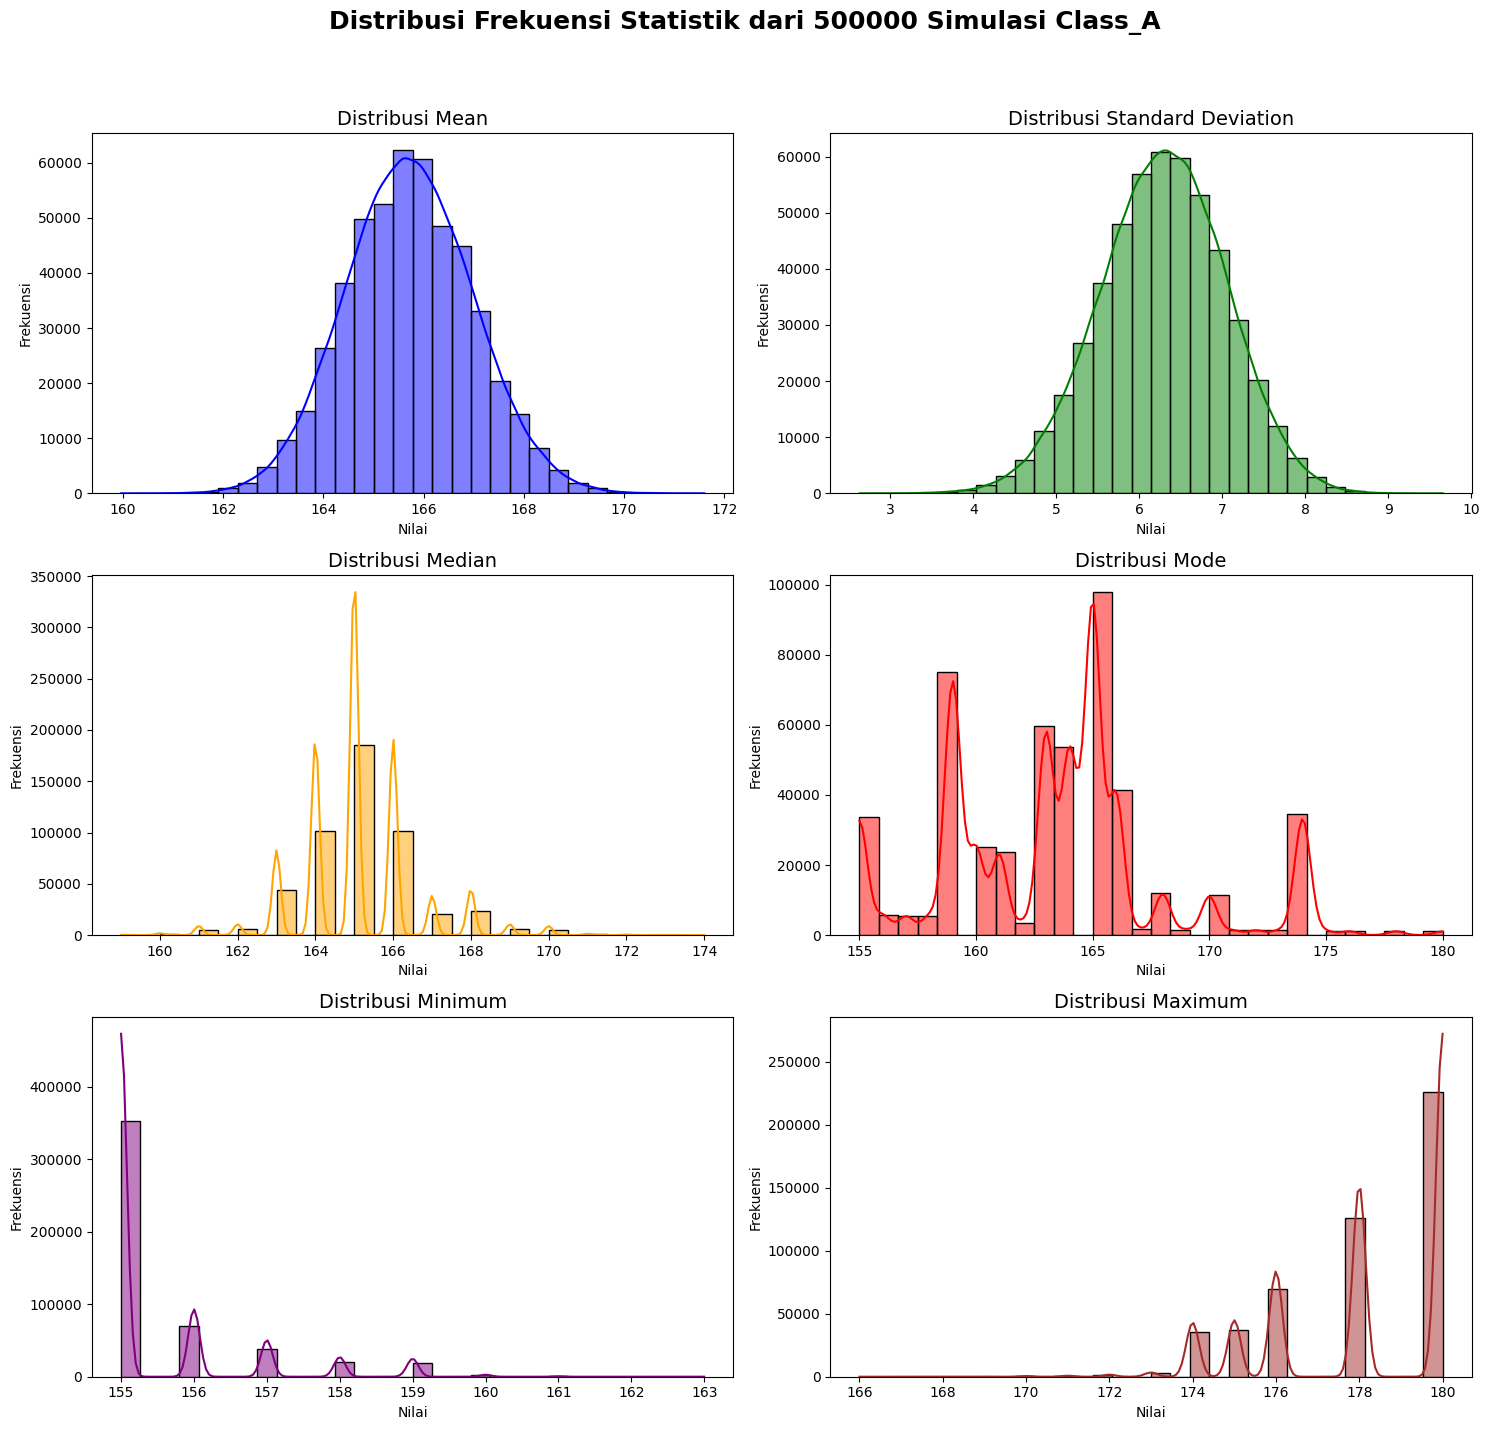

In [37]:
import seaborn as sns
from scipy import stats

n_simulations = 500000
sample_size = 25

means, stds, medians, modes, mins, maxs = [], [], [], [], [], []

for _ in range(n_simulations):
    sample = np.random.choice(Class_A, size=sample_size, replace=True)
    means.append(np.mean(sample))
    stds.append(np.std(sample, ddof=1))
    medians.append(np.median(sample))
    mins.append(np.min(sample))
    maxs.append(np.max(sample))
    modes.append(stats.mode(sample, keepdims=True).mode[0])

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle(f'Distribusi Frekuensi Statistik dari {n_simulations} Simulasi Class_A', fontsize=18, fontweight='bold')

metrics = [
    (means, 'Mean', 'blue'), (stds, 'Standard Deviation', 'green'),
    (medians, 'Median', 'orange'), (modes, 'Mode', 'red'),
    (mins, 'Minimum', 'purple'), (maxs, 'Maximum', 'brown')
]

for i, (data, title, color) in enumerate(metrics):
    ax = axes[i//2, i%2]
    sns.histplot(data, bins=30, kde=True, ax=ax, color=color)
    ax.set_title(f'Distribusi {title}', fontsize=14)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. See the pattern of those frequency distribution. Are they close to the normal distribution?
### Berdasarkan hasil visualisasi dari 500.000 simulasi tersebut, dapat disimpulkan bahwa hanya distribusi Mean (Rata-rata) dan Standard Deviation (Simpangan Baku) yang menunjukkan karakteristik distribusi normal. Hal ini ditandai dengan bentuk kurva yang simetris menyerupai lonceng (bell curve), di mana data berpusat di tengah dan frekuensinya melandai secara halus di kedua sisi ekor. Fenomena pada distribusi Mean ini memperkuat hukum statistik Central Limit Theorem, yang menyatakan bahwa rata-rata dari sampel yang besar akan cenderung mengikuti distribusi normal meskipun data aslinya tidak.

### Sebaliknya, distribusi Median, Mode, Minimum, dan Maximum dikategorikan sebagai distribusi tidak normal karena memiliki pola penyebaran yang berbeda. Distribusi Median dan Mode menunjukkan bentuk yang tidak beraturan atau multimodal (memiliki banyak puncak), sementara distribusi Minimum dan Maximum menunjukkan kemiringan yang ekstrem (skewed). Data pada nilai minimum menumpuk di sisi kiri (skewed right), sedangkan nilai maksimum menumpuk di sisi kanan (skewed left), yang membuktikan bahwa nilai-nilai ekstrem dalam statistik cenderung tidak mengikuti pola distribusi normal yang simetris.

## 5. Take 25 random samples (uniformly distributed random number) of student's height from class B and calculate its mean, standard deviation, median, mode, minimum, and maximum.

### Prosedur penyelesaian untuk instruksi ini mengadopsi metodologi yang identik dengan tahapan pada soal nomor 2. Seluruh pendekatan analitis dan teknik komputasi yang sebelumnya telah diterapkan tetap digunakan sebagai kerangka utama dalam menjalankan kalkulasi pada bagian ini.

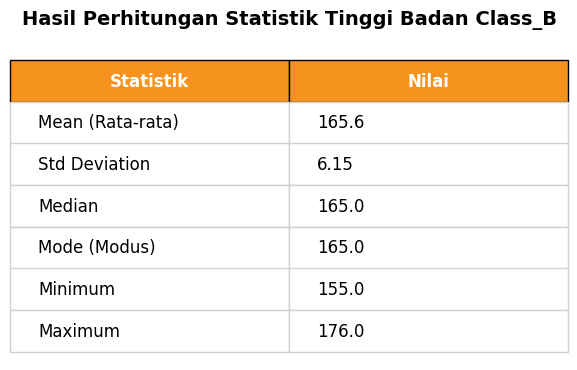

In [38]:
np.random.seed(42)
sampel_25 = np.random.choice(Class_B, size=25, replace=True)
mean_val = np.mean(sampel_25)
std_val = np.std(sampel_25, ddof=1)
median_val = np.median(sampel_25)
mode_val = stats.mode(sampel_25, keepdims=True)[0][0]
min_val = np.min(sampel_25)
max_val = np.max(sampel_25)

def plot_stat_table(stats_dict, title):
    df = pd.DataFrame(list(stats_dict.items()), columns=['Statistik', 'Nilai'])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.axis('off')

    the_table = ax.table(cellText=df.values,
                         colLabels=df.columns,
                         loc='center',
                         cellLoc='left',
                         colColours=["#f6921e"] * 2)

    the_table.auto_set_font_size(False)
    the_table.set_fontsize(12)
    the_table.scale(1.2, 2.5)

    for k, cell in the_table.get_celld().items():
        if k[0] == 0:
            cell.set_text_props(weight='bold', color='white')
        else:
            cell.set_edgecolor('#d1d1d1')

    plt.title(title, fontsize=14, pad=20, weight='bold')
    plt.show()

data_statistik = {
    'Mean (Rata-rata)': 165.60,
    'Std Deviation': 6.15,
    'Median': 165.00,
    'Mode (Modus)': 165,
    'Minimum': 155,
    'Maximum': 176
}

plot_stat_table(data_statistik, "Hasil Perhitungan Statistik Tinggi Badan Class_B")

## 6. Repeat instruction 5 until 500.000 times and draw the frequency distribution graph of those 500.000 means, standard deviations, medians, modes, minimum, and maximum.
### Metode iterasi yang diterapkan pada instruksi nomor 5 mengadopsi prosedur yang serupa dengan instruksi nomor 3, yaitu melakukan looping sebanyak 500.000 kali terhadap looping pada instruksi nomor 2. Perbedaan fundamental pada tahapan ini terletak pada dataset yang digunakan, di mana seluruh proses komputasi kini difokuskan pada Class_B, menggantikan dataset Class_A yang digunakan pada prosedur sebelumnya.

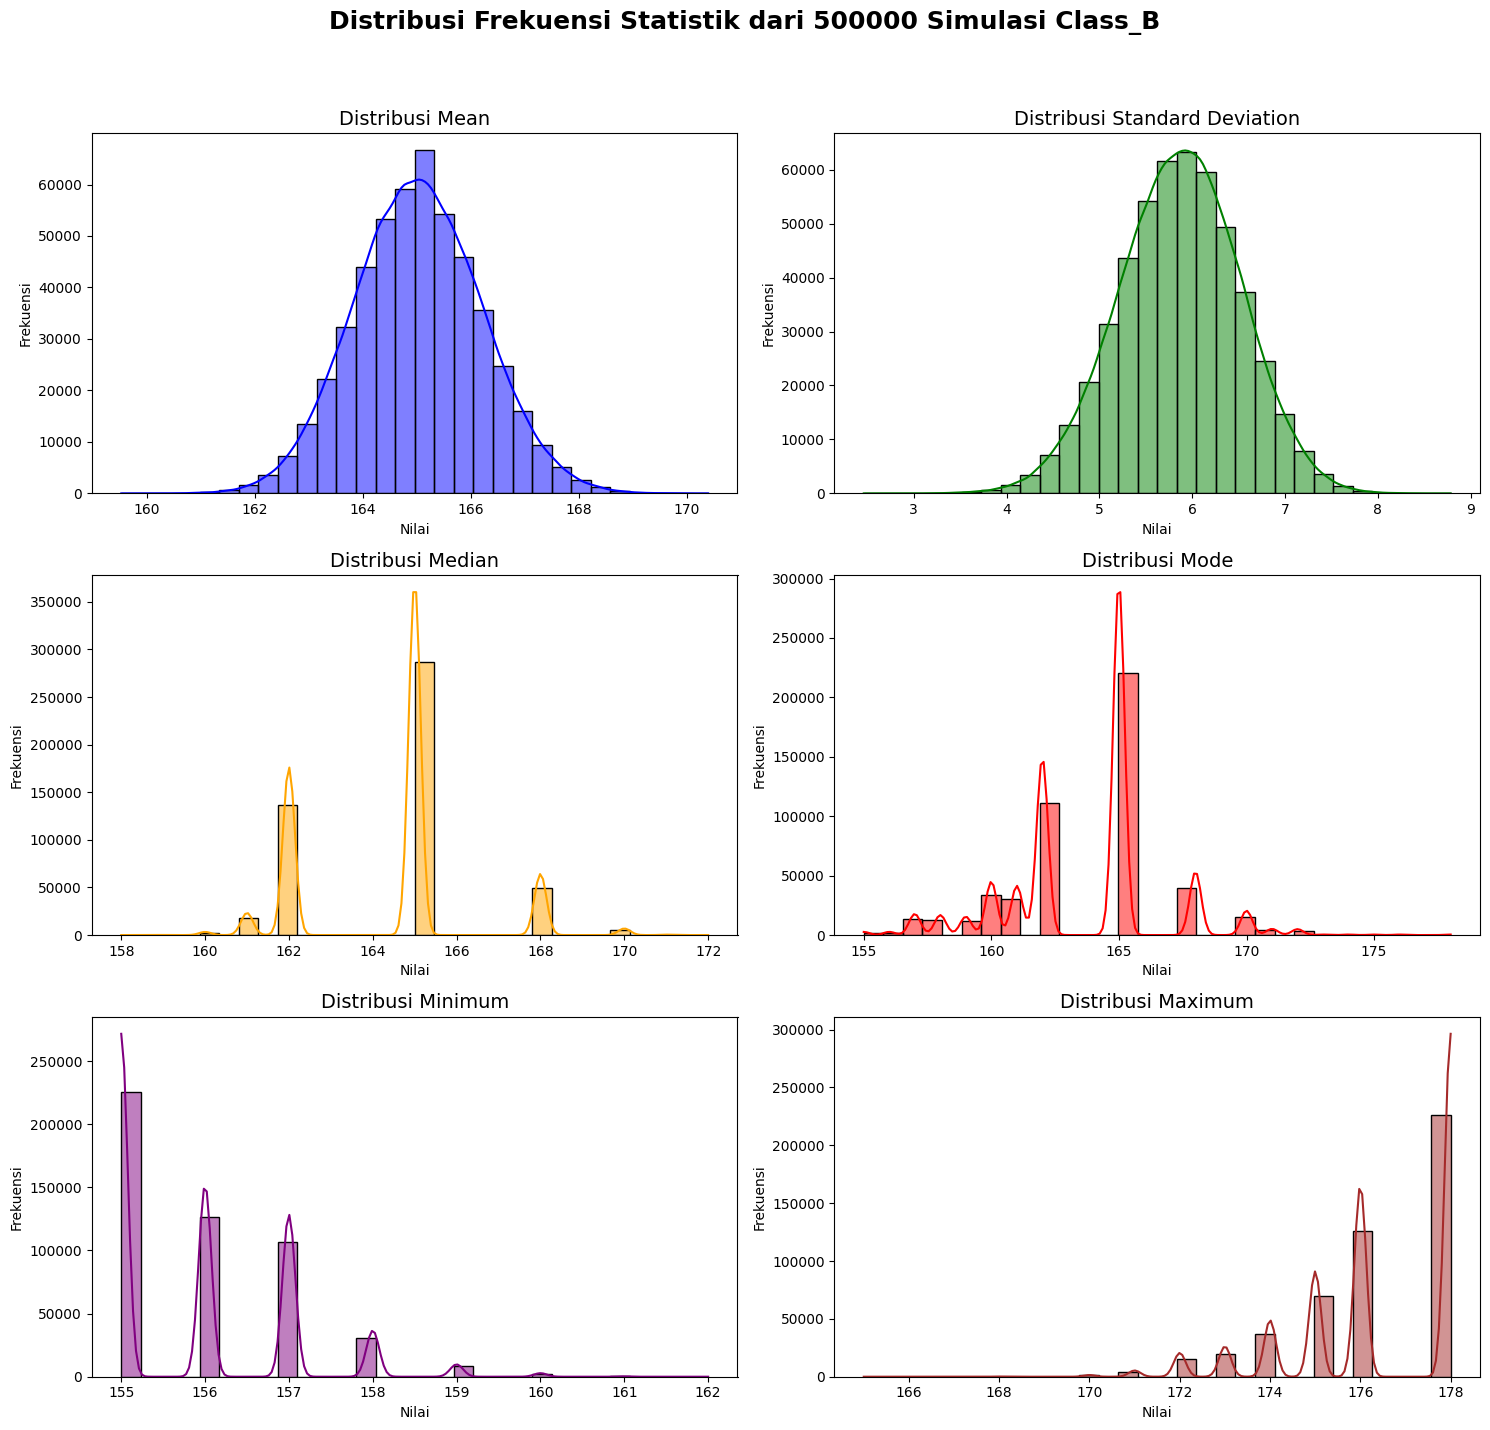

In [39]:
import seaborn as sns
from scipy import stats

n_simulations = 500000
sample_size = 25

means, stds, medians, modes, mins, maxs = [], [], [], [], [], []

for _ in range(n_simulations):
    sample = np.random.choice(Class_B, size=sample_size, replace=True)
    means.append(np.mean(sample))
    stds.append(np.std(sample, ddof=1))
    medians.append(np.median(sample))
    mins.append(np.min(sample))
    maxs.append(np.max(sample))
    modes.append(stats.mode(sample, keepdims=True).mode[0])

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle(f'Distribusi Frekuensi Statistik dari {n_simulations} Simulasi Class_B', fontsize=18, fontweight='bold')

metrics = [
    (means, 'Mean', 'blue'), (stds, 'Standard Deviation', 'green'),
    (medians, 'Median', 'orange'), (modes, 'Mode', 'red'),
    (mins, 'Minimum', 'purple'), (maxs, 'Maximum', 'brown')
]

for i, (data, title, color) in enumerate(metrics):
    ax = axes[i//2, i%2]
    sns.histplot(data, bins=30, kde=True, ax=ax, color=color)
    ax.set_title(f'Distribusi {title}', fontsize=14)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 7. See the pattern of those frequency distribution. Are they close to the normal distribution?


### Berdasarkan hasil visualisasi dari 500.000 simulasi untuk **Class_B** tersebut, dapat disimpulkan bahwa distribusi **Mean** (Biru) dan **Standard Deviation** (Hijau) merupakan satu-satunya yang menunjukkan karakteristik **distribusi normal**. Kedua grafik ini memiliki bentuk kurva lonceng (*bell curve*) yang sangat simetris, di mana data berpusat secara konsisten pada titik rata-rata dan frekuensinya menurun secara merata ke arah kedua ekor. Fenomena pada distribusi Mean ini adalah bukti nyata dari *Central Limit Theorem*, yang memastikan bahwa distribusi rata-rata sampel akan selalu mendekati normal seiring dengan besarnya jumlah simulasi yang dilakukan.


### Sebaliknya, distribusi **Median, Mode, Minimum,** dan **Maximum** menunjukkan karakteristik **distribusi tidak normal** yang sangat kontras. Grafik Median dan Mode terlihat sangat terfragmentasi dengan beberapa puncak tajam yang terpisah (*multimodal*), menunjukkan bahwa nilai-nilai tersebut cenderung berkumpul pada titik-titik diskrit tertentu daripada menyebar secara kontinu. Sementara itu, distribusi Minimum menunjukkan kemiringan ke kanan (*skewed right*) dengan penumpukan frekuensi ekstrem di angka rendah, dan distribusi Maximum menunjukkan kemiringan ke kiri (*skewed left*) dengan penumpukan frekuensi di angka tinggi, yang secara statistik membuktikan bahwa nilai batas ekstrem tidak mengikuti pola distribusi normal yang seimbang.

